In [1]:
# retrieving functions from lindbladian.ipnyb
%run '/home/jovyan/NSERC 2026/[1] [lindbladian helper code] [may 19]/lindbladian.ipynb'

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [3]:
J = sp.Symbol("J", real=True, positive=True)
epsilon  = sp.Symbol("epsilon", real=True, positive=True)
gamma = sp.Symbol("Gamma", real=True, positive=True)
delta = sp.Symbol("delta", real=True, positive=True)
Delta1, Delta2, Delta3  = sp.symbols("Delta1 Delta2 Delta3", real=True, positive=True)
Delta31, Delta32, Delta21 = sp.symbols("Delta31 Delta32 Delta21", real=True, positive=True)
t = sp.Symbol("t", real=True, positive=True)


In [4]:
def plot_time_series(axs, N, matrix, J_val, epsilon_val, gamma_vals, initial_condition, pop_indices, label=True, reduced_matrix=False, dt=1e1):
    # iterating through different dephasing regimes
    for col, gamma_val in enumerate(gamma_vals):
        
        # for each regime, compute long time-scale value
        lambda1 = 2*N*gamma_val*epsilon_val**2 / ( gamma_val**2 + J_val**2 )
        #lambda2 = 4*gamma_val*epsilon_val**2 / ( gamma_val**2 + J_val**2 ) + 2*(N-2)*epsilon_val**2 / gamma_val
        timescale = 1/lambda1
        print(timescale)

        # numerically compute time evolution of density matrix
        times, rhos = solve_lindblad_num(
            matrix.subs({J:J_val, gamma:gamma_val, epsilon:epsilon_val}),
            0.1,
            timescale*1e2,
            timescale*dt,
            initial_condition,
        )

        # plotting populations
        num_dimers = N - len(pop_indices)
        for i, index in enumerate(pop_indices):
            if (i in range(num_dimers)) and reduced_matrix:
                axs[col].plot(times, 
                              rhos[index],
                              label=rf"$\frac{{|{{{2*i+1}}}⟩⟨{{{2*i+1}}}|+|{{{2*i+2}}}⟩⟨{{{2*i+2}}}|}}{{\sqrt2}}$",
                              linewidth=2*0.95**i,
                              alpha=1*0.95**i
                             )
                axs[col].plot([], []) # null plot to increment color cycle
                
            else:
                axs[col].plot(times, 
                              rhos[index],
                              label=f"{num_dimers+i+1 if reduced_matrix else i+1}",
                              linewidth=2*0.95**i,
                              alpha=1*0.95**i
                             )

        # labelling
        if label: axs[col].set_title(fr'$\Gamma=10^{{{int(np.log10(gamma_vals[col]))}}}$')
        #axs[col].set_ylim(bottom=0.2, top=1.4)
        axs[col].set_xlabel("Time (s)")
        axs[col].set_xscale('log')
        axs[col].legend(title="Site Pop.:", fontsize="x-small", title_fontsize="x-small", ncol = 1, loc = "upper right")
        axs[col].axvline(1/lambda1,linestyle="--", color="gray", zorder=-1)
        #axs[col].axvline(1/lambda2,linestyle="--", color="black", zorder=-1)

    # labelling
    #axs[0].set_ylabel("Site Populations")


In [6]:
H = [[0.00000000e+00+0.j, 1.04615989e-01+0.j, 1.70594859e-02+0.j,
  1.08494889e-04+0.j, 1.08182783e-04+0.j, 4.65042193e-05+0.j,
  2.15801123e-05+0.j, 1.31159768e-05+0.j, 7.72356342e-06+0.j,
  7.23761251e-06+0.j],
 [1.04615989e-01+0.j, 0.00000000e+00+0.j, 1.07698802e-02+0.j,
  1.34724185e-04+0.j, 1.47527041e-04+0.j, 5.81718598e-05+0.j,
  2.34701313e-05+0.j, 1.51048713e-05+0.j, 8.77304188e-06+0.j,
  7.77509164e-06+0.j],
 [1.70594859e-02+0.j, 1.07698802e-02+0.j, 0.00000000e+00+0.j,
  1.54474721e-04+0.j, 1.13094614e-04+0.j, 3.90146844e-05+0.j,
  2.85745711e-05+0.j, 1.15513922e-05+0.j, 7.78893771e-06+0.j,
  8.63145411e-06+0.j],
 [1.08494889e-04+0.j, 1.34724185e-04+0.j, 1.54474721e-04+0.j,
  0.00000000e+00+0.j, 6.86126234e-04+0.j, 5.54557590e-05+0.j,
  2.09188804e-04+0.j, 1.64522500e-05+0.j, 2.12581869e-05+0.j,
  3.28738582e-05+0.j],
 [1.08182783e-04+0.j, 1.47527041e-04+0.j, 1.13094614e-04+0.j,
  6.86126234e-04+0.j, 0.00000000e+00+0.j, 3.01312480e-04+0.j,
  5.23843287e-05+0.j, 4.46967681e-05+0.j, 3.78958640e-05+0.j,
  1.76831331e-05+0.j],
 [4.65042193e-05+0.j, 5.81718598e-05+0.j, 3.90146844e-05+0.j,
  5.54557590e-05+0.j, 3.01312480e-04+0.j, 0.00000000e+00+0.j,
  1.42806810e-05+0.j, 3.09783757e-04+0.j, 4.33593885e-05+0.j,
  7.56452306e-06+0.j],
 [2.15801123e-05+0.j, 2.34701313e-05+0.j, 2.85745711e-05+0.j,
  2.09188804e-04+0.j, 5.23843287e-05+0.j, 1.42806810e-05+0.j,
  0.00000000e+00+0.j, 6.98713339e-06+0.j, 1.46293839e-05+0.j,
  2.20075383e-04+0.j],
 [1.31159768e-05+0.j, 1.51048713e-05+0.j, 1.15513922e-05+0.j,
  1.64522500e-05+0.j, 4.46967681e-05+0.j, 3.09783757e-04+0.j,
  6.98713339e-06+0.j, 0.00000000e+00+0.j, 6.05619344e-05+0.j,
  4.91481169e-06+0.j],
 [7.72356342e-06+0.j, 8.77304188e-06+0.j, 7.78893771e-06+0.j,
  2.12581869e-05+0.j, 3.78958640e-05+0.j, 4.33593885e-05+0.j,
  1.46293839e-05+0.j, 6.05619344e-05+0.j, 0.00000000e+00+0.j,
  1.51885699e-05+0.j],
 [7.23761251e-06+0.j, 7.77509164e-06+0.j, 8.63145411e-06+0.j,
  3.28738582e-05+0.j, 1.76831331e-05+0.j, 7.56452306e-06+0.j,
  2.20075383e-04+0.j, 4.91481169e-06+0.j, 1.51885699e-05+0.j,
  0.00000000e+00+0.j]]

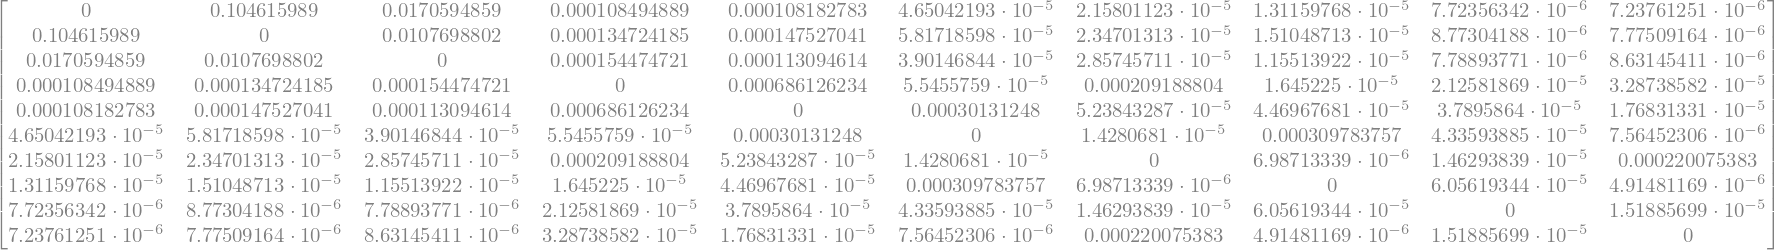

In [7]:
H = sp.Matrix(H)
H

In [8]:
# building lindblad jump operators
L_operators = [sp.Matrix(10,10, lambda i,j: 1 if i==k and j==k else 0) for k in range(10)]

# building lindbladians
L, rho = lindbladian(10, output=False, degenerate=False, H=H, L_operators=L_operators)
L = L.subs({sp.Symbol(f"Gamma_{i}", real=True, nonnegative=True):gamma for i in range(10)})

1000000.0000000002
50005000.00000001
5000000050.000001


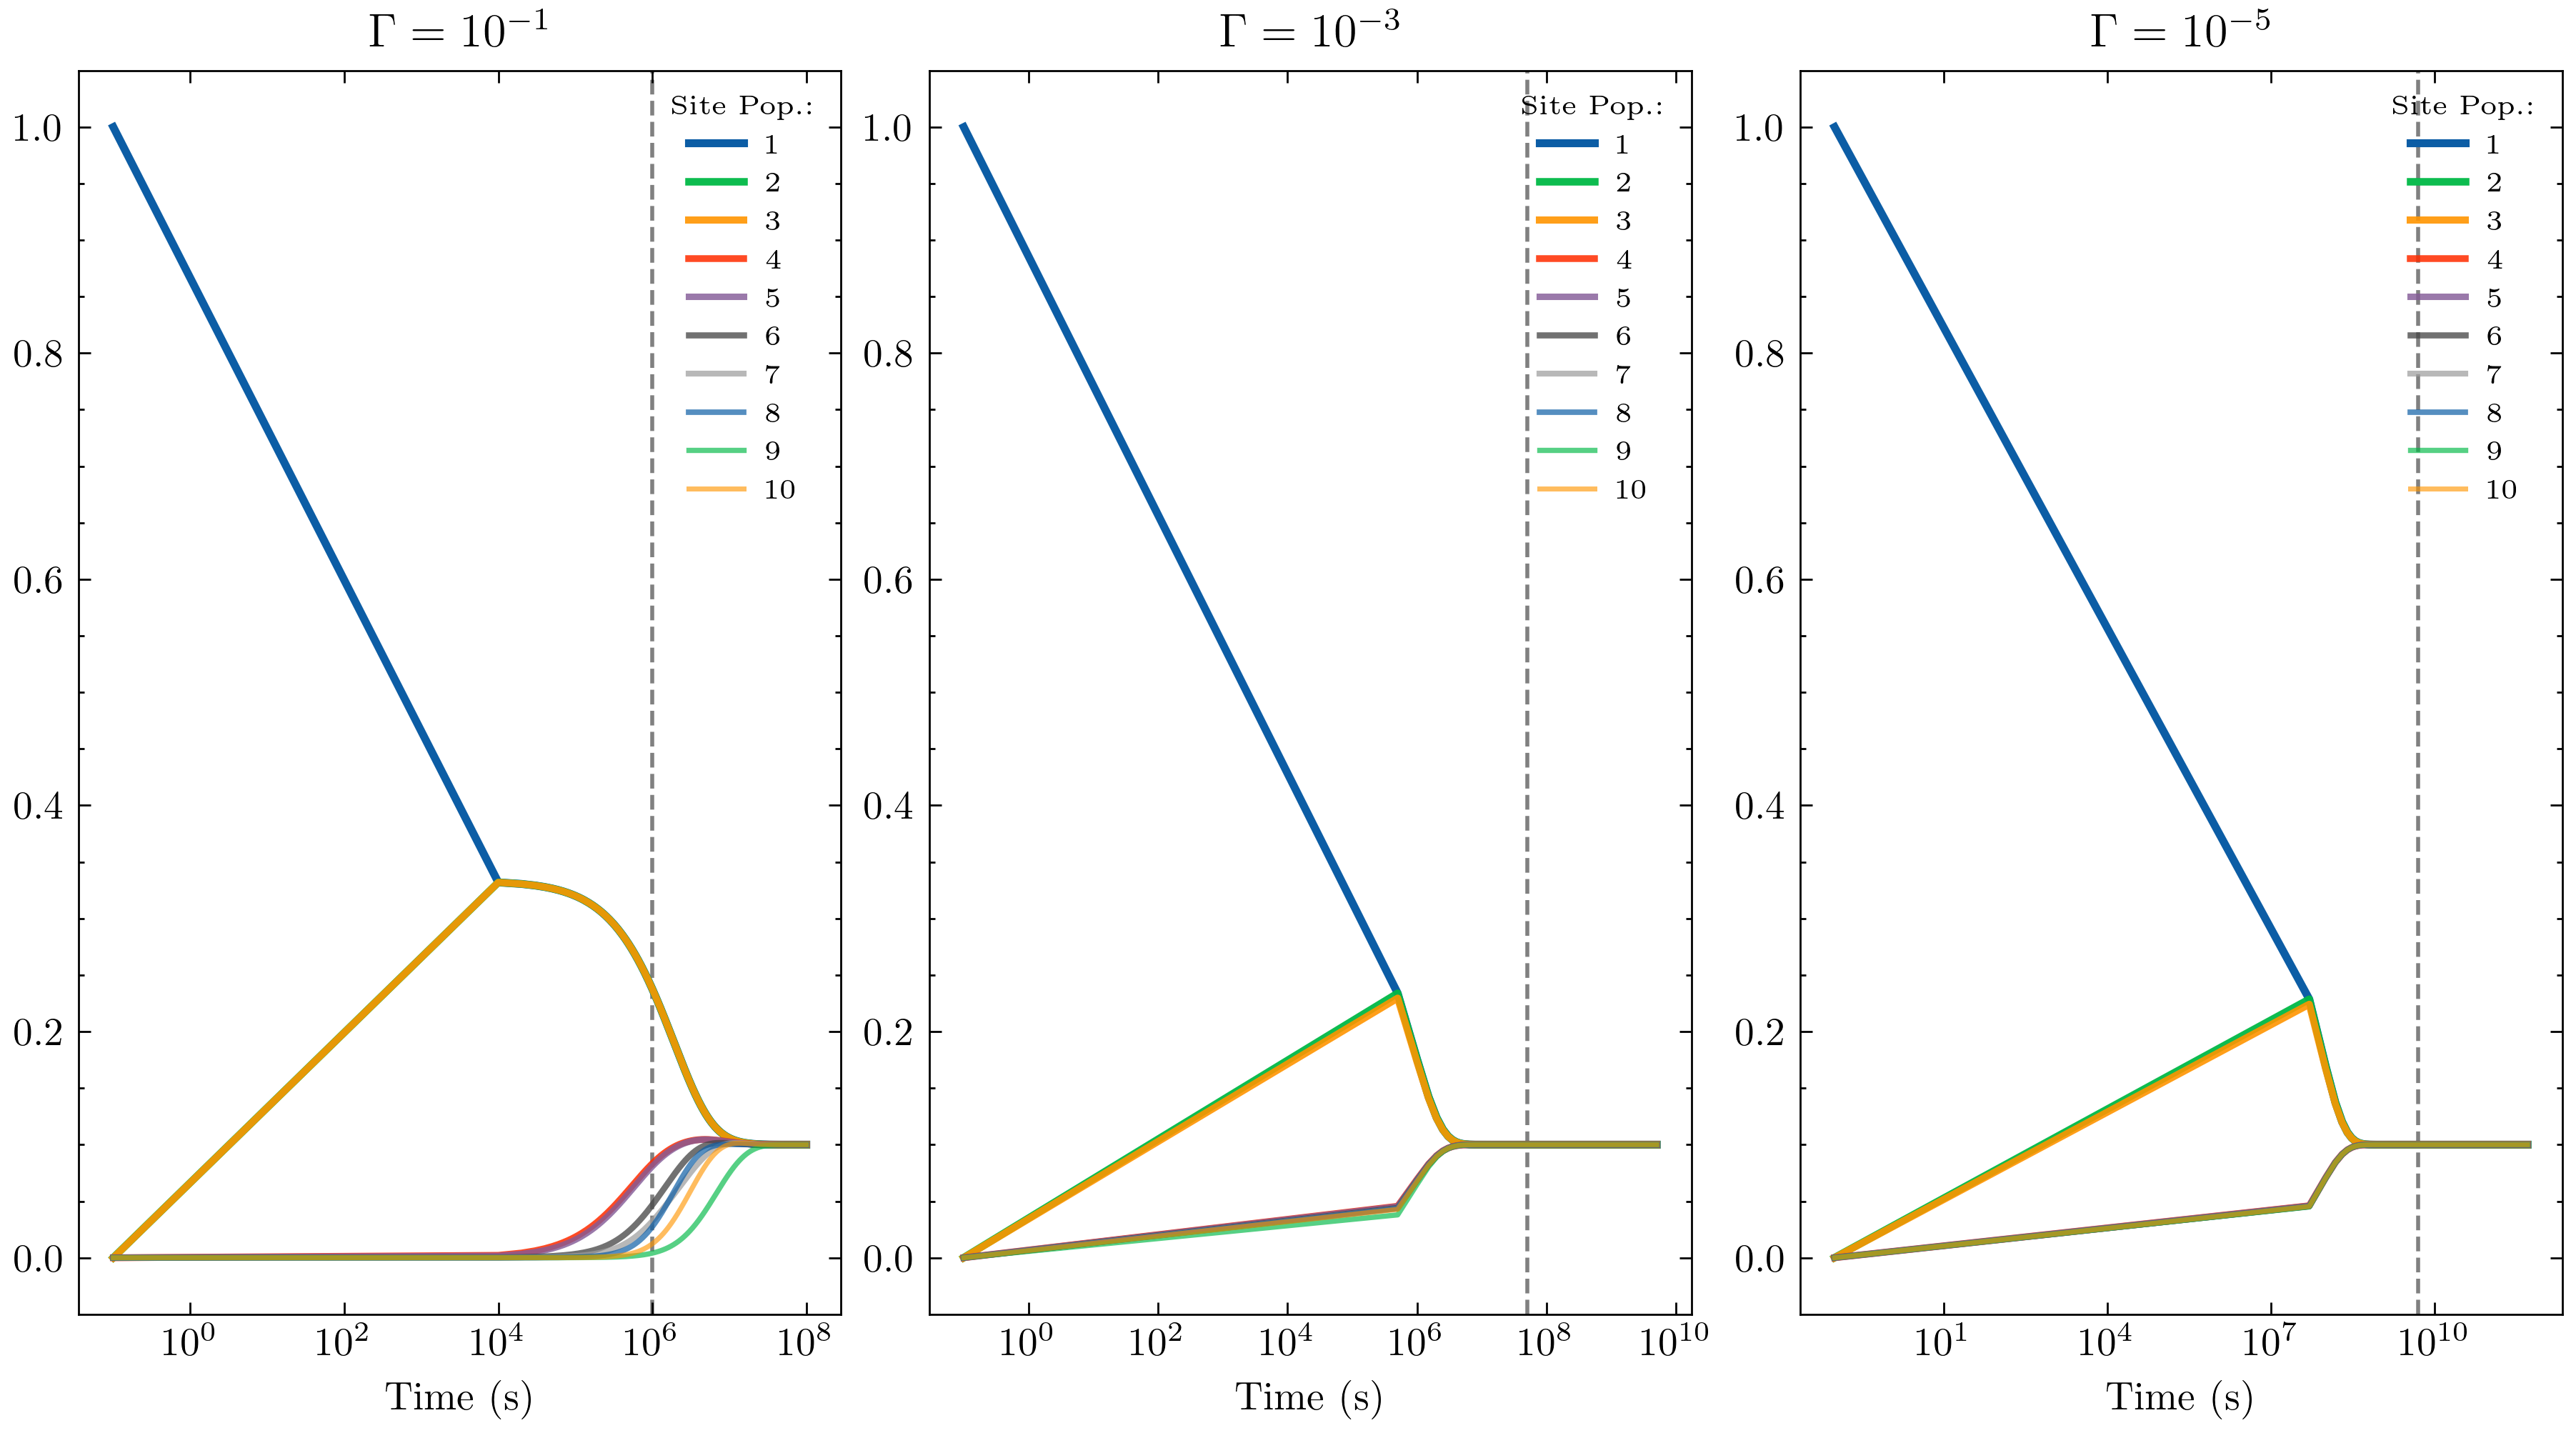

In [14]:
gamma_vals = [1e-1, 1e-3, 1e-5]
J_val=0.1
epsilon_val=1e-4


initial_pops = [1,0,0,0,0,0,0,0,0,0]


fig, axs = plt.subplots(1,3, figsize=(9, 5), layout='constrained')

plot_time_series(axs, 10, L, J_val, epsilon_val, gamma_vals, np.diag(initial_pops).reshape(10**2), (11)*np.arange(10), label=True, reduced_matrix=False, dt=1e-2)






In [ ]:
started at 4:44pm